## Base Datasets Info

In [2]:
import os
import geopandas as gpd
import rasterio

# === UPDATED PATHS ===
raw_base = r"F:\_____My_Thesies____\_ImpFiles"

# Spectral TIFF
data_dir = os.path.join(
    raw_base,
    "3. Feature Selection",
    "_Sentinel Data",
    "2. Divided Data",
    "2.Spectral"
) 
year = 2024
spectral_tif = os.path.join(data_dir, f"{year}_Opt_SR.tif")

# Reference shapefile for training/testing
ref_shp = os.path.join(
    raw_base,
    "2.Segments",
    "_Final_Reference_Combined",
    "Ref_2024.shp"
)

# Segmented OBIA polygon shapefile with band means
seg_shp = os.path.join(
    raw_base,
    "3. Feature Selection",
    "_Sentinel Data",
    "2. Divided Data",
    "6.Segmentation",
    "Seg_2024",
    "1. Opt",
    "2024_Seg_With_Mean_Opt.shp"
)

# --- 1) LOAD REFERENCE SHAPEFILE ---
print("📂 Reference Shapefile path:", ref_shp)
ref_gdf = gpd.read_file(ref_shp)
print("✅ Reference shapefile loaded")
print("Columns:", ref_gdf.columns.tolist())
print("Number of polygons:", len(ref_gdf))
print("Unique classes in 'layer':", ref_gdf["layer"].unique())

# --- 2) LOAD SEGMENTED SHAPEFILE ---
print("\n📂 Segmented Shapefile path:", seg_shp)
seg_gdf = gpd.read_file(seg_shp)
print("✅ Segmented shapefile loaded")
print("Columns:", seg_gdf.columns.tolist())
print("Number of segments:", len(seg_gdf))

📂 Reference Shapefile path: F:\_____My_Thesies____\_ImpFiles\2.Segments\_Final_Reference_Combined\Ref_2024.shp
✅ Reference shapefile loaded
Columns: ['fid_1', 'Name', 'descriptio', 'layer', 'path', 'Feature_ID', 'Area', 'geometry']
Number of polygons: 206
Unique classes in 'layer': ['Wheat-polygon' 'Rice-polygon' 'Clover-polygon' 'Alfalfa-polygon'
 'Corn-polygon' 'Sugar_Beet-polygon' 'Urban-polygon' 'Plowed-polygon'
 'Phragmites-polygon' 'Degreed_Wetland_Poly-polygon' 'Tamarix-polygon'
 'Mixed_TP-polygon' 'Bare-polygon']

📂 Segmented Shapefile path: F:\_____My_Thesies____\_ImpFiles\3. Feature Selection\_Sentinel Data\2. Divided Data\6.Segmentation\Seg_2024\1. Opt\2024_Seg_With_Mean_Opt.shp
✅ Segmented shapefile loaded
Columns: ['PXLVAL', '_b1_mean', '_b2_mean', '_b3_mean', '_b4_mean', '_b5_mean', '_b6_mean', '_b7_mean', '_b8_mean', '_b9_mean', '_b10_mean', '_b11_mean', '_b12_mean', '_b13_mean', '_b14_mean', '_b15_mean', '_b16_mean', '_b17_mean', '_b18_mean', '_b19_mean', '_b20_mean', '

## Rename Main Bands

In [3]:
import numpy as np
import pandas as pd
from tqdm import tqdm

def map_band_names(seg_gdf, band_names_file):
    """
    Map generic band names (_bX_mean) to real band names from the provided file
    """
    print("\n🗺️ Mapping generic band names to real band names")
    
    # Load the band names from the file
    with open(band_names_file, 'r') as f:
        all_band_names = [line.strip() for line in f.readlines()]
    
    # Separate optical and SAR bands
    optical_band_names = [name for name in all_band_names if name.startswith('B')]
    sar_band_names = [name for name in all_band_names if name.startswith(('VV','VH'))]
    
    print(f"- Found {len(optical_band_names)} optical bands and {len(sar_band_names)} SAR bands in names file")
    
    # Create mapping for optical bands
    band_name_mapping = {}
    used_optical_bands = 0
    band_cols = [col for col in seg_gdf.columns if col.startswith('_b')]
    
    for col in band_cols:
        try:
            band_num = int(col.split('_')[1][1:])
            if used_optical_bands < len(optical_band_names):
                band_name_mapping[col] = optical_band_names[used_optical_bands]
                used_optical_bands += 1
            else:
                band_name_mapping[col] = f"Optical_Band_{band_num}"
        except:
            band_name_mapping[col] = col
    
    # Rename the columns in the GeoDataFrame
    seg_gdf = seg_gdf.rename(columns=band_name_mapping)
    print(f"- Mapped {used_optical_bands} optical bands to real names")
    print("- Sample of renamed columns:", list(seg_gdf.columns[1:6]))  # Show first few renamed columns
    
    return seg_gdf
# First map the band names
band_names_file = r"F:\_____My_Thesies____\_ImpFiles\3. Feature Selection\_Sentinel Data\2. Divided Data\_Bands_Names\2024_SR Bands Names.txt"
seg_gdf_with_names = map_band_names(seg_gdf, band_names_file)



🗺️ Mapping generic band names to real band names
- Found 730 optical bands and 122 SAR bands in names file
- Mapped 730 optical bands to real names
- Sample of renamed columns: ['B2_20240105', 'B3_20240105', 'B4_20240105', 'B5_20240105', 'B6_20240105']


## PreProcess Data


In [4]:
def preprocess_segmented_data(seg_gdf, ref_gdf):
    """
    Preprocess the segmented data by:
    1. Removing columns with >50% NaN values
    2. Filling remaining NaN values using temporal interpolation
    Now works with real band names
    """
    seg_gdf = seg_gdf.copy()
    
    # ==================================================================
    # STEP 1: Remove columns with >50% NaN values
    # ==================================================================
    print("\n🔍 STEP 1: Identifying and removing columns with >50% NaN values")
    
    # Get all band columns (now using real names)
    band_cols = [col for col in seg_gdf.columns if col.startswith(('B', 'VV', 'VH'))]  # Optical and SAR bands
    total_segments = len(seg_gdf)
    threshold = total_segments * 0.5
    
    cols_to_drop = []
    for col in band_cols:
        nan_count = seg_gdf[col].isna().sum()
        if nan_count > threshold:
            cols_to_drop.append(col)
            print(f"  - Column {col} has {nan_count}/{total_segments} NaN values ({(nan_count/total_segments)*100:.1f}%) - will be dropped")
    
    seg_gdf = seg_gdf.drop(columns=cols_to_drop)
    remaining_bands = [col for col in seg_gdf.columns if col.startswith(('B', 'VV', 'VH'))]
    print(f"✅ Completed. Dropped {len(cols_to_drop)} columns. Remaining {len(remaining_bands)} bands")
    
    # ==================================================================
    # STEP 2: Fill remaining NaN values using temporal interpolation
    # ==================================================================
    print("\n🔍 STEP 2: Filling remaining NaN values using temporal interpolation")
    
    # First pass: Fill with monthly mean (now using real band names with dates)
    print("  - Filling with monthly mean values where possible...")
    for col in tqdm(remaining_bands, desc="Processing bands"):
        try:
            # Extract date from band name (assuming format like 'B20240101' for Jan 1, 2024)
            date_str = col[1:9]  # Skip first character (B/V) and get YYYYMMDD
            year_month = date_str[:6]  # Get YYYYMM
            
            # Find other bands from same month
            same_month_cols = [c for c in remaining_bands 
                              if c[1:7] == year_month]  # Compare YYYYMM parts
            
            if len(same_month_cols) > 1:  # Need at least one other band
                monthly_means = seg_gdf[same_month_cols].mean(axis=1)
                seg_gdf[col] = seg_gdf[col].fillna(monthly_means)
        except:
            continue
    
    # Second pass: Fill with seasonal mean (previous, current, next month)
    print("  - Filling remaining gaps with seasonal mean (prev+current+next month)...")
    for col in tqdm(remaining_bands, desc="Processing bands"):
        if not seg_gdf[col].isna().any():
            continue
            
        try:
            # Extract date from band name
            date_str = col[1:9]
            year = int(date_str[:4])
            month = int(date_str[4:6])
            
            # Find bands from adjacent months
            prev_month = month - 1 if month > 1 else 12
            next_month = month + 1 if month < 12 else 1
            
            # Handle year change for December/January
            prev_year = year if month > 1 else year - 1
            next_year = year if month < 12 else year + 1
            
            # Format strings for adjacent months
            prev_pattern = f"{prev_year}{prev_month:02d}"
            next_pattern = f"{next_year}{next_month:02d}"
            
            # Find matching columns
            seasonal_cols = []
            for c in remaining_bands:
                c_date = c[1:7]  # Get YYYYMM part
                if c_date in [date_str[:6], prev_pattern, next_pattern]:
                    seasonal_cols.append(c)
            
            if len(seasonal_cols) > 1:
                seasonal_mean = seg_gdf[seasonal_cols].mean(axis=1)
                seg_gdf[col] = seg_gdf[col].fillna(seasonal_mean)
        except:
            continue
    
    # Final pass: Fill with yearly mean for any remaining NaNs
    print("  - Filling any remaining gaps with yearly mean...")
    for col in tqdm(remaining_bands, desc="Processing bands"):
        if seg_gdf[col].isna().any():
            yearly_mean = seg_gdf[remaining_bands].mean(axis=1)
            seg_gdf[col] = seg_gdf[col].fillna(yearly_mean)
    
    remaining_nans = seg_gdf[remaining_bands].isna().sum().sum()
    print(f"✅ Completed. Total remaining NaN values: {remaining_nans}")
    
    # ==================================================================
    # STEP 3: Prepare final dataset
    # ==================================================================
    print("\n📊 Final dataset summary:")
    print(f"- Total segments processed: {len(seg_gdf)}")
    print(f"- Total reference polygons: {len(ref_gdf)}")
    print(f"- Remaining bands: {len(remaining_bands)}")
    print("- Sample of processed data:")
    print(seg_gdf[remaining_bands[:5]].head())
    
    return seg_gdf

processed_seg_gdf = preprocess_segmented_data(seg_gdf_with_names, ref_gdf)



🔍 STEP 1: Identifying and removing columns with >50% NaN values
  - Column B2_20240120 has 3949/6311 NaN values (62.6%) - will be dropped
  - Column B3_20240120 has 3949/6311 NaN values (62.6%) - will be dropped
  - Column B4_20240120 has 3949/6311 NaN values (62.6%) - will be dropped
  - Column B5_20240120 has 3949/6311 NaN values (62.6%) - will be dropped
  - Column B6_20240120 has 3949/6311 NaN values (62.6%) - will be dropped
  - Column B7_20240120 has 3949/6311 NaN values (62.6%) - will be dropped
  - Column B8_20240120 has 3949/6311 NaN values (62.6%) - will be dropped
  - Column B8A_20240120 has 3949/6311 NaN values (62.6%) - will be dropped
  - Column B11_20240120 has 3949/6311 NaN values (62.6%) - will be dropped
  - Column B12_20240120 has 3949/6311 NaN values (62.6%) - will be dropped
  - Column B2_20240219 has 3801/6311 NaN values (60.2%) - will be dropped
  - Column B3_20240219 has 3801/6311 NaN values (60.2%) - will be dropped
  - Column B4_20240219 has 3801/6311 NaN val

Processing bands: 100%|██████████| 600/600 [00:09<00:00, 65.75it/s]


  - Filling remaining gaps with seasonal mean (prev+current+next month)...


Processing bands: 100%|██████████| 600/600 [00:00<00:00, 5938.53it/s]


  - Filling any remaining gaps with yearly mean...


Processing bands: 100%|██████████| 600/600 [00:00<00:00, 7699.13it/s]


✅ Completed. Total remaining NaN values: 0

📊 Final dataset summary:
- Total segments processed: 6311
- Total reference polygons: 206
- Remaining bands: 600
- Sample of processed data:
   B2_20240105  B3_20240105  B4_20240105  B5_20240105  B6_20240105
0   755.000000   980.000000  1230.000000  1507.000000  1606.000000
1   682.666667   966.666667  1017.666667  1333.000000  2051.000000
2   601.250000   811.500000   976.500000  1503.000000  2158.000000
3   750.600000   941.200000  1118.400000  1330.600000  1569.200000
4   731.000000   999.250000  1131.166667  1446.833333  1864.666667


## Add VIs

In [11]:
import numpy as np
import pandas as pd
from tqdm import tqdm

def calculate_all_indices(image_data):
    """
    Calculate 18 vegetation indices from Sentinel-2 bands
    """
    indices = {}
    blue = image_data[0] / 10000
    green = image_data[1] / 10000
    red = image_data[2] / 10000
    red_edge1 = image_data[3] / 10000
    red_edge2 = image_data[4] / 10000
    red_edge3 = image_data[5] / 10000
    nir = image_data[6] / 10000
    red_edge4 = image_data[7] / 10000
    swir1 = image_data[8] / 10000
    swir2 = image_data[9] / 10000
    L = 0.5

    indices['NDVI'] = (nir - red) / (nir + red + 1e-6)
    indices['EVI'] = 2.5 * ((nir - red) / (nir + 6 * red - 7.5 * blue + 1))
    indices['SAVI'] = ((nir - red) / (nir + red + L)) * (1 + L)
    indices['TDVI'] = 1.5 * ((nir - red) / np.sqrt((nir ** 2 + red + 0.5)))
    indices['NDWI'] = (green - nir) / (green + nir + 1e-6)
    indices['2BDA'] = red_edge1 / (red + 1e-6)
    indices['NDCI'] = (red_edge1 - red) / (red_edge1 + red + 1e-6)
    indices['ENDVI'] = ((nir + green) - 2 * blue) / ((nir + green) + 2 * blue + 1e-6)
    indices['GNDVI'] = (nir - green) / (nir + green + 1e-6)
    indices['NDRE'] = (nir - red_edge2) / (nir + red_edge2 + 1e-6)
    indices['GRVI'] = nir / (green + 1e-6)
    indices['MSAVI'] = (2 * nir + 1 - np.sqrt((2 * nir + 1) ** 2 - 8 * (nir - red))) / 2
    indices['LSWI'] = (nir - swir1) / (nir + swir1 + 1e-6)
    indices['NDMI'] = (nir - swir1) / (nir + swir1 + 1e-6)
    indices['MNDWI'] = (green - swir1) / (green + swir1 + 1e-6)
    indices['MBI'] = ((swir1 - swir2 - nir) / (swir1 + swir2 + nir + 1e-6)) + 0.5
    indices['EMBI'] = (indices['MBI'] - indices['MNDWI'] - 0.5) / (indices['MBI'] + indices['MNDWI'] + 1.5)
    indices['MCARI2'] = 1.5 * (2.5 * (nir - red) - 1.3 * (nir - green)) / (
        np.sqrt((2 * nir + 1) ** 2 - (6 * nir - 5 * np.sqrt(red + 1e-6))) - 0.5
    )
    return indices

def calculate_vIs_for_all_dates(processed_seg_gdf):
    """
    Calculate vegetation indices for all dates in the processed dataframe
    """
    print("\n🌱 Calculating Vegetation Indices for all dates")
    
    # Get all band columns (they start with B, VV, or VH)
    band_cols = [col for col in processed_seg_gdf.columns if col.startswith(('B', 'VV', 'VH'))]
    
    # Extract unique dates from band names (assuming format B_YYYYMMDD)
    dates = sorted(list(set(col.split('_')[1] for col in band_cols if '_' in col)))
    print(f"- Found {len(dates)} unique dates")
    
    # Create a dictionary to map band numbers to positions
    band_mapping = {
        'B2': 0,   # Blue
        'B3': 1,    # Green
        'B4': 2,    # Red
        'B5': 3,    # Red Edge 1
        'B6': 4,    # Red Edge 2
        'B7': 5,    # Red Edge 3
        'B8': 6,    # NIR
        'B8A': 7,   # Red Edge 4
        'B11': 8,   # SWIR1
        'B12': 9    # SWIR2
    }
    
    # Rest of the function remains the same...
    vi_dfs = []
    
    for date in tqdm(dates, desc="Processing dates"):
        # Get all bands for this date
        date_bands = [col for col in band_cols if date in col]
        
        # Check if we have all required bands for this date
        required_bands = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
        has_all_bands = all(any(b in col for col in date_bands) for b in required_bands)
        
        if not has_all_bands:
            print(f"  - Skipping date {date} - missing required bands")
            continue
        
        # Create a temporary array with bands in correct order
        band_data = np.zeros((len(processed_seg_gdf), 10))
        for band_name, pos in band_mapping.items():
            # Find the column for this band and date
            band_col = next((col for col in date_bands if band_name in col), None)
            if band_col is not None:
                band_data[:, pos] = processed_seg_gdf[band_col].values
        
        # Calculate VIs for all segments at this date
        vi_results = []
        for i in range(len(processed_seg_gdf)):
            vis = calculate_all_indices(band_data[i])
            vis['date'] = date
            vi_results.append(vis)
        
        # Create dataframe for this date
        date_df = pd.DataFrame(vi_results)
        date_df['segment_id'] = processed_seg_gdf.index
        vi_dfs.append(date_df)
    
    # Combine all dates
    if not vi_dfs:
        raise ValueError("No valid dates with complete band data found!")
    
    final_vi_df = pd.concat(vi_dfs)
    
    # Convert date string to datetime and sort
    final_vi_df['date'] = pd.to_datetime(final_vi_df['date'], format='%Y%m%d')
    final_vi_df = final_vi_df.sort_values(['segment_id', 'date'])
    
    # Reset index
    final_vi_df = final_vi_df.reset_index(drop=True)
    
    print(f"\n✅ Completed. Calculated {len(final_vi_df)} VI records")
    print(f"- Time range: {final_vi_df['date'].min().strftime('%Y-%m-%d')} to {final_vi_df['date'].max().strftime('%Y-%m-%d')}")
    print(f"- Total segments: {final_vi_df['segment_id'].nunique()}")
    print(f"- Sample data:")
    print(final_vi_df.head())
    
    return final_vi_df

# Calculate all vegetation indices
final_vi_df = calculate_vIs_for_all_dates(processed_seg_gdf)

# Optional: Save to file
# output_path = "F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/2. Divided Data/7.VIs/2024_VIs.csv"
# final_vi_df.to_csv(output_path, index=False)
# print(f"\n💾 Saved results to {output_path}")


🌱 Calculating Vegetation Indices for all dates
- Found 59 unique dates


Processing dates:   0%|          | 0/59 [00:00<?, ?it/s]

Processing dates: 100%|██████████| 59/59 [00:12<00:00,  4.81it/s]



✅ Completed. Calculated 372349 VI records
- Time range: 2024-01-05 to 2024-12-30
- Total segments: 6311
- Sample data:
       NDVI       EVI      SAVI      TDVI      NDWI      2BDA      NDCI  \
0  0.209511  0.119857  0.120562  0.120528 -0.315163  1.225193  0.101205   
1  0.165123  0.076774  0.084563  0.080820 -0.333332  1.188529  0.086148   
2  0.512693  0.364911  0.348926  0.381756 -0.547096  1.468274  0.189721   
3  0.210180  0.106303  0.103281  0.097700 -0.269594  1.230756  0.103448   
4  0.235209  0.119122  0.104808  0.096418 -0.246417  1.242559  0.108167   

      ENDVI     GNDVI      NDRE      GRVI     MSAVI      LSWI      NDMI  \
0  0.309240  0.315163  0.079128  1.920389  0.102351 -0.040285 -0.040285   
1  0.352642  0.333332  0.043899  1.999974  0.069449 -0.093909 -0.093909   
2  0.533996  0.547096  0.127688  3.415920  0.327339  0.235942  0.235942   
3  0.251751  0.269594  0.047619  1.738187  0.084615 -0.014706 -0.014706   
4  0.156906  0.246417  0.064871  1.653971  0.084487  0

In [13]:
def merge_vi_with_spectral(processed_seg_gdf, final_vi_df):
    """
    Merge vegetation indices with original spectral data
    """
    print("\n🔀 Merging vegetation indices with spectral data")
    
    # 1. Prepare the spectral data for merging
    # First, create a copy with segment_id as a column (not index)
    spectral_df = processed_seg_gdf.reset_index().rename(columns={'index': 'segment_id'})
    
    # Get all band columns (they start with B, VV, or VH)
    band_cols = [col for col in spectral_df.columns if col.startswith(('B', 'VV', 'VH'))]
    
    # Melt the band columns into long format
    spectral_long = pd.melt(
        spectral_df,
        id_vars=['segment_id', 'geometry'],
        value_vars=band_cols,
        var_name='band_date',
        value_name='value'
    )
    
    # Extract band and date from band names (handling both B2_20240105 and B20240105 formats)
    spectral_long['band'] = spectral_long['band_date'].apply(
        lambda x: x.split('_')[0] if '_' in x else x[:2] if x.startswith('B') else x[:2]
    )
    spectral_long['date_str'] = spectral_long['band_date'].apply(
        lambda x: x.split('_')[1] if '_' in x else x[2:10] if x.startswith('B') else x[2:10]
    )
    
    # Convert to datetime (handle cases where date_str might be malformed)
    spectral_long['date'] = pd.to_datetime(spectral_long['date_str'], errors='coerce', format='%Y%m%d')
    
    # Drop rows with invalid dates
    spectral_long = spectral_long.dropna(subset=['date'])
    
    # Pivot back to wide format (one row per segment-date combination)
    spectral_by_date = spectral_long.pivot_table(
        index=['segment_id', 'date'],
        columns='band',
        values='value',
        aggfunc='first'  # Take the first value if there are duplicates
    ).reset_index()
    
    # Clean up column names
    spectral_by_date.columns.name = None
    spectral_by_date.columns = [f"{col}_value" if col not in ['segment_id', 'date'] else col for col in spectral_by_date.columns]
    
    # 2. Merge with vegetation indices
    # Ensure date columns are in the same format
    final_vi_df['date'] = pd.to_datetime(final_vi_df['date'])
    
    # Perform the merge
    merged_df = pd.merge(
        final_vi_df,
        spectral_by_date,
        on=['segment_id', 'date'],
        how='left'
    )
    
    # 3. Add geometry back (from original segments)
    # Create a geometry lookup table (segment_id to geometry)
    geo_lookup = processed_seg_gdf[['geometry']].reset_index().rename(columns={'index': 'segment_id'})
    merged_df = pd.merge(
        merged_df,
        geo_lookup,
        on='segment_id',
        how='left'
    )
    
    # 4. Final organization
    # Reorder columns to put identifiers first
    col_order = ['segment_id', 'date', 'geometry'] + \
                [col for col in merged_df.columns if col not in ['segment_id', 'date', 'geometry']]
    merged_df = merged_df[col_order]
    
    print("\n✅ Merge completed successfully")
    print(f"- Final shape: {merged_df.shape}")
    print(f"- Time range: {merged_df['date'].min().strftime('%Y-%m-%d')} to {merged_df['date'].max().strftime('%Y-%m-%d')}")
    print(f"- Columns in merged dataframe:")
    print(merged_df.columns.tolist())
    print("\nSample of merged data:")
    print(merged_df.head())
    
    return merged_df

# Perform the merge
final_merged_df = merge_vi_with_spectral(processed_seg_gdf, final_vi_df)

# Optional: Save to file
# output_path = "F:/_____My_Thesies____/_ImpFiles/3. Feature Selection/_Sentinel Data/2. Divided Data/8.Merged/2024_FullDataset.csv"
# final_merged_df.to_csv(output_path, index=False)
# print(f"\n💾 Saved merged data to {output_path}")


🔀 Merging vegetation indices with spectral data

✅ Merge completed successfully
- Final shape: (372349, 31)
- Time range: 2024-01-05 to 2024-12-30
- Columns in merged dataframe:
['segment_id', 'date', 'geometry', 'NDVI', 'EVI', 'SAVI', 'TDVI', 'NDWI', '2BDA', 'NDCI', 'ENDVI', 'GNDVI', 'NDRE', 'GRVI', 'MSAVI', 'LSWI', 'NDMI', 'MNDWI', 'MBI', 'EMBI', 'MCARI2', 'B11_value', 'B12_value', 'B2_value', 'B3_value', 'B4_value', 'B5_value', 'B6_value', 'B7_value', 'B8_value', 'B8A_value']

Sample of merged data:
   segment_id       date                                           geometry  \
0           0 2024-01-05  POLYGON ((48.761 33.83576, 48.76118 33.83576, ...   
1           0 2024-01-10  POLYGON ((48.761 33.83576, 48.76118 33.83576, ...   
2           0 2024-01-25  POLYGON ((48.761 33.83576, 48.76118 33.83576, ...   
3           0 2024-01-30  POLYGON ((48.761 33.83576, 48.76118 33.83576, ...   
4           0 2024-02-04  POLYGON ((48.761 33.83576, 48.76118 33.83576, ...   

       NDVI     

### Train Model

In [18]:
# ========================================================
# STEP 1: Prepare Features (Direct VI + Spectral Values)
# ========================================================
print("\n🔍 STEP 1: Preparing features using direct VI and spectral values")

# First, ensure final_merged_df is a GeoDataFrame
if not isinstance(final_merged_df, gpd.GeoDataFrame):
    final_merged_gdf = gpd.GeoDataFrame(
        final_merged_df, 
        geometry=gpd.GeoSeries(final_merged_df['geometry'])
    )
else:
    final_merged_gdf = final_merged_df

# Spatial join between segments and reference polygons
joined_gdf = gpd.sjoin(
    final_merged_gdf, 
    ref_gdf[['layer', 'geometry']], 
    how='inner', 
    predicate='intersects'
)

# Get the most frequent label for each segment (in case a segment intersects multiple polygons)
segment_labels = joined_gdf.groupby('segment_id')['layer'].agg(lambda x: x.mode()[0]).reset_index()

# Encode class labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(segment_labels['layer'])

# Prepare feature matrix by keeping only one row per segment (the first observation)
unique_segments = joined_gdf.drop_duplicates('segment_id', keep='first')
features = []

for segment_id in tqdm(segment_labels['segment_id'].unique(), desc="Processing segments"):
    # Get all temporal observations for this segment
    segment_data = joined_gdf[joined_gdf['segment_id'] == segment_id]
    
    # Sort by date to maintain temporal order
    segment_data = segment_data.sort_values('date')
    
    # Create feature dictionary
    segment_feature = {'segment_id': segment_id}
    
    # Add all VI and spectral values with date prefixes
    for _, row in segment_data.iterrows():
        date_str = row['date'].strftime('%Y%m%d')
        
        # Add all 18 VIs
        for vi in ['NDVI', 'EVI', 'SAVI', 'TDVI', 'NDWI', '2BDA', 'NDCI', 'ENDVI', 
                  'GNDVI', 'NDRE', 'GRVI', 'MSAVI', 'LSWI', 'NDMI', 'MNDWI', 
                  'MBI', 'EMBI', 'MCARI2']:
            segment_feature[f'{date_str}_{vi}'] = row[vi]
            
        # Add all 10 spectral bands
        for band in ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']:
            segment_feature[f'{date_str}_{band}'] = row[f'{band}_value']
    
    features.append(segment_feature)

# Convert to DataFrame
X = pd.DataFrame(features)

# Ensure X and y have the same length
assert len(X) == len(y), "Feature matrix and target vector must have same length"

print(f"\n✅ Feature preparation completed")
print(f"- Total segments: {X.shape[0]}")
print(f"- Total features per segment: {X.shape[1] - 1}")  # minus segment_id
print("- Sample features:", list(X.columns[:10]))

# ========================================================
# STEP 2: Train-Test Split (70-30)
# ========================================================
print("\n🔍 STEP 2: Splitting data into training (70%) and test (30%) sets")

X_train, X_test, y_train, y_test = train_test_split(
    X.drop('segment_id', axis=1), 
    y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y
)

print(f"✅ Data split completed:")
print(f"- Training samples: {X_train.shape[0]}")
print(f"- Test samples: {X_test.shape[0]}")



🔍 STEP 1: Preparing features using direct VI and spectral values


Processing segments: 100%|██████████| 927/927 [00:22<00:00, 42.09it/s]



✅ Feature preparation completed
- Total segments: 927
- Total features per segment: 1652
- Sample features: ['segment_id', '20240105_NDVI', '20240105_EVI', '20240105_SAVI', '20240105_TDVI', '20240105_NDWI', '20240105_2BDA', '20240105_NDCI', '20240105_ENDVI', '20240105_GNDVI']

🔍 STEP 2: Splitting data into training (70%) and test (30%) sets
✅ Data split completed:
- Training samples: 648
- Test samples: 279



🔍 STEP 3: Training Random Forest with 5-fold cross-validation

📊 Cross-Validation Results:
- Fold accuracies: [0.77692308 0.73846154 0.79230769 0.71317829 0.73643411]
- Mean CV accuracy: 0.7515 ± 0.0289

✅ Model trained on full training set

🔍 STEP 4: Comprehensive evaluation on test set

📊 Comprehensive Test Set Performance:

Overall Metrics:
- Accuracy: 0.7599
- Balanced Accuracy: 0.4596
- Cohen's Kappa: 0.6856
- Macro F1-Score: 0.4789

Class-wise Metrics:
                       Class  Precision   Recall  F1-Score  Support
             Alfalfa-polygon   0.692308 0.600000  0.642857       30
                Bare-polygon   0.894737 0.850000  0.871795       20
              Clover-polygon   0.750000 0.250000  0.375000       12
                Corn-polygon   0.000000 0.000000  0.000000        5
Degreed_Wetland_Poly-polygon   0.000000 0.000000  0.000000        3
            Mixed_TP-polygon   0.333333 0.333333  0.333333        3
          Phragmites-polygon   0.750000 0.272727  0.400000  

c:\Users\mamad_js\anaconda3\envs\rs\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


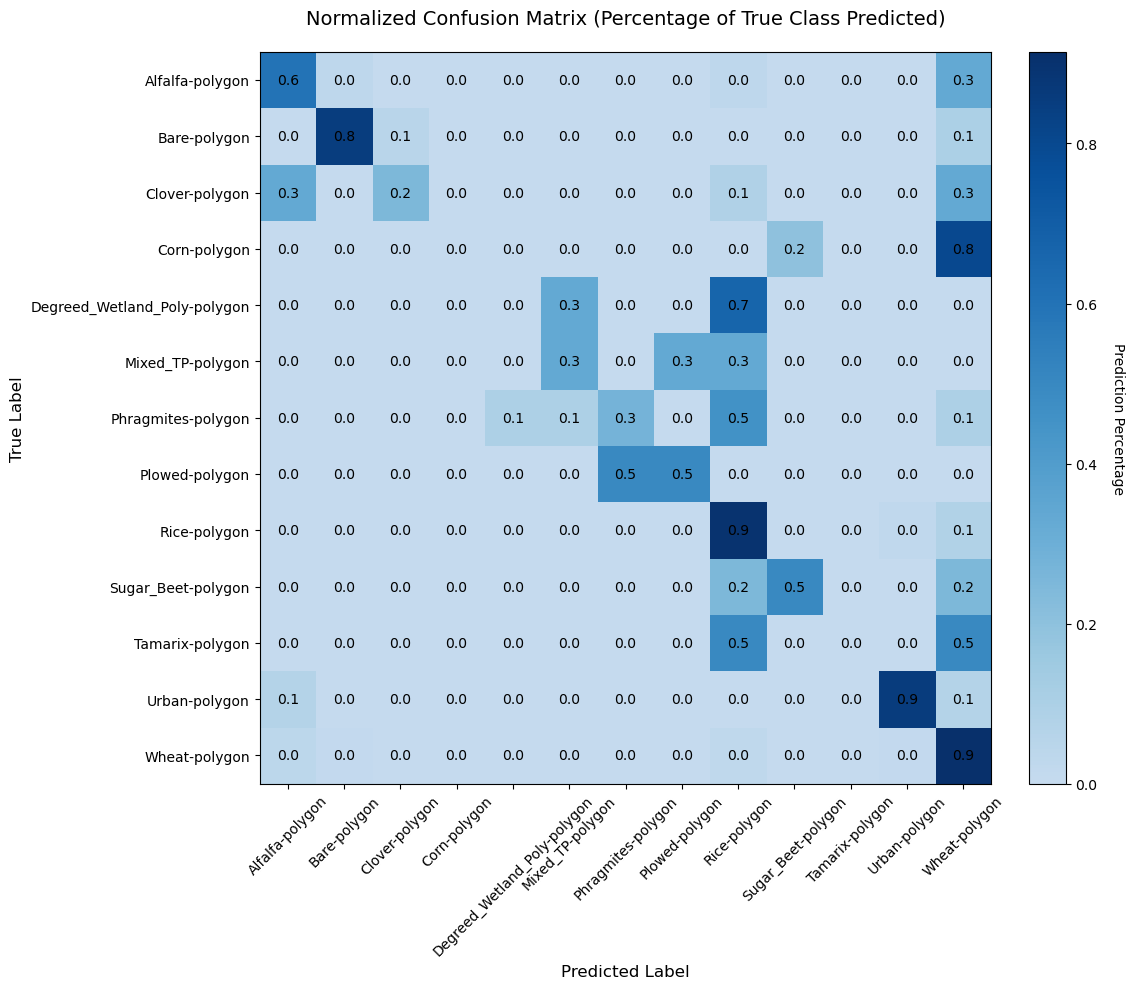


⚠️ Could not plot ROC curves: name 'RocCurveDisplay' is not defined


<Figure size 1000x800 with 0 Axes>

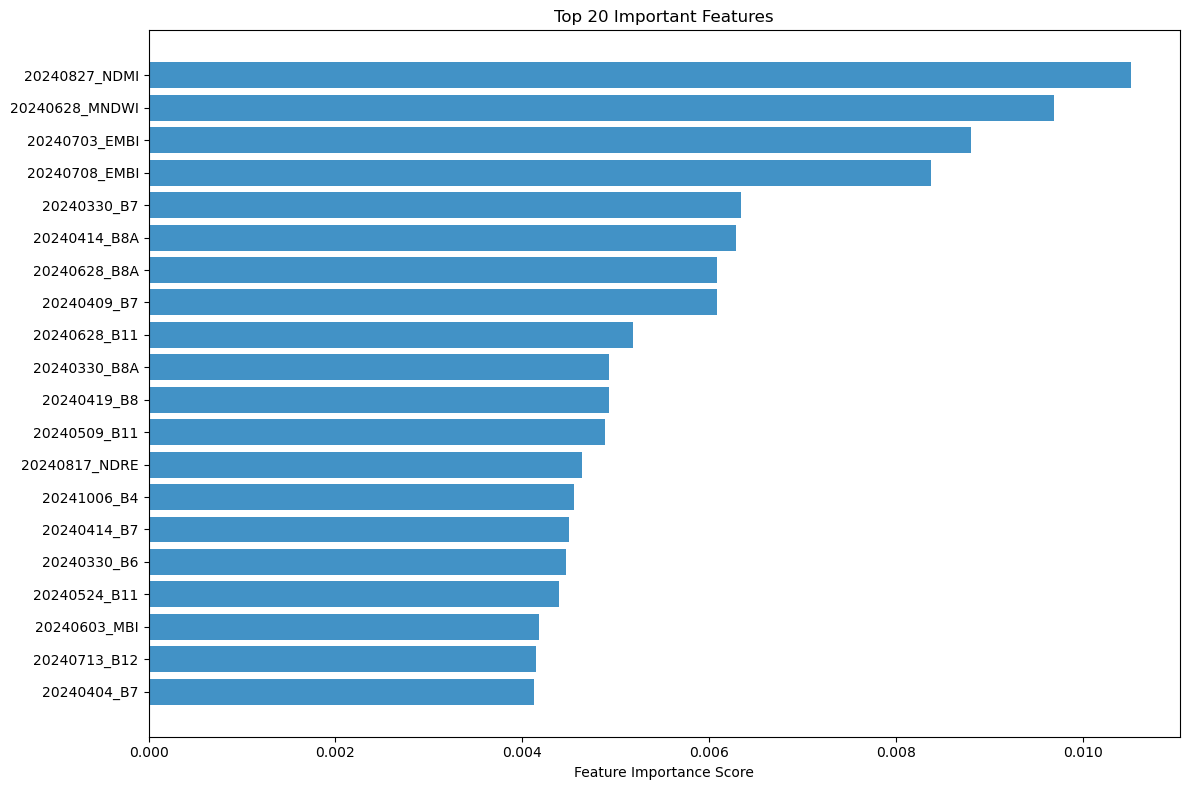

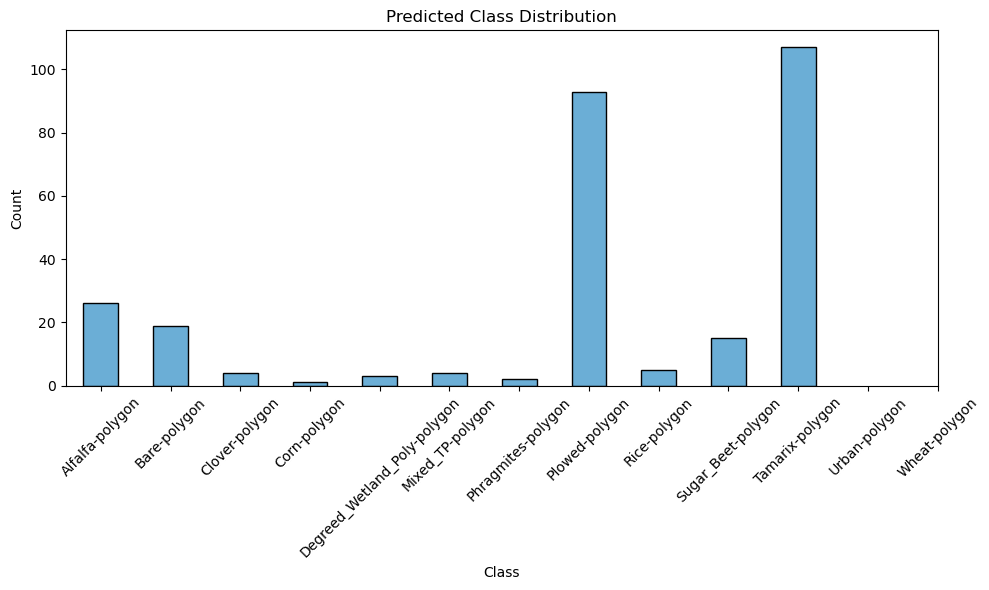


📊 Additional Evaluation Metrics:

One-vs-Rest ROC AUC Scores:
- Alfalfa-polygon: 0.9309
- Bare-polygon: 0.9875
- Clover-polygon: 0.9582
- Corn-polygon: 0.6734
- Degreed_Wetland_Poly-polygon: 0.9499
- Mixed_TP-polygon: 0.9752
- Phragmites-polygon: 0.9858
- Plowed-polygon: 0.9883
- Rice-polygon: 0.9594
- Sugar_Beet-polygon: 0.9958
- Tamarix-polygon: 0.9170
- Urban-polygon: 0.9945
- Wheat-polygon: 0.9413
- Macro Average: 0.9428

Classification Report:
                              precision    recall  f1-score   support

             Alfalfa-polygon     0.6923    0.6000    0.6429        30
                Bare-polygon     0.8947    0.8500    0.8718        20
              Clover-polygon     0.7500    0.2500    0.3750        12
                Corn-polygon     0.0000    0.0000    0.0000         5
Degreed_Wetland_Poly-polygon     0.0000    0.0000    0.0000         3
            Mixed_TP-polygon     0.3333    0.3333    0.3333         3
          Phragmites-polygon     0.7500    0.2727    0.

c:\Users\mamad_js\anaconda3\envs\rs\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\mamad_js\anaconda3\envs\rs\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\mamad_js\anaconda3\envs\rs\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:

# ========================================================
# STEP 3: Train Random Forest with 5-Fold CV
# ========================================================
print("\n🔍 STEP 3: Training Random Forest with 5-fold cross-validation")

# Initialize Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1  # Use all available cores
)

# 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train, y_train, cv=kf, scoring='accuracy')

print("\n📊 Cross-Validation Results:")
print(f"- Fold accuracies: {cv_scores}")
print(f"- Mean CV accuracy: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

# Train final model on full training set
rf.fit(X_train, y_train)
print("\n✅ Model trained on full training set")

# ========================================================
# STEP 4: Enhanced Evaluation on Test Set
# ========================================================
print("\n🔍 STEP 4: Comprehensive evaluation on test set")

from sklearn.metrics import (precision_score, recall_score, f1_score, 
                            balanced_accuracy_score, cohen_kappa_score,
                            roc_auc_score, classification_report, 
                            confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.colors as mcolors

# Generate predictions
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)

# ====================
# 1. Numerical Metrics
# ====================
print("\n📊 Comprehensive Test Set Performance:")

# Basic metrics
accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

# Class-wise metrics
precision = precision_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)

# Create metrics dataframe
metrics_df = pd.DataFrame({
    'Class': label_encoder.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': np.bincount(y_test)
})

# Print overall metrics
print(f"\nOverall Metrics:")
print(f"- Accuracy: {accuracy:.4f}")
print(f"- Balanced Accuracy: {balanced_acc:.4f}")
print(f"- Cohen's Kappa: {kappa:.4f}")
print(f"- Macro F1-Score: {macro_f1:.4f}")

# Print detailed class metrics
print("\nClass-wise Metrics:")
print(metrics_df.to_string(index=False))

# ====================
# 2. Visualizations
# ====================

# Custom color palette
cmap = mcolors.LinearSegmentedColormap.from_list(
    'custom', ['#f7fbff', '#4292c6', '#08306b'], N=256)

# 2.1 Enhanced Confusion Matrix
plt.figure(figsize=(12, 10))  # Adjusted size for better readability

# Create custom blue color gradient
cmap = plt.cm.Blues(np.linspace(0, 1, 256))
cmap = mcolors.ListedColormap(cmap[64:, :-1])  # Skip the very lightest blues

disp = ConfusionMatrixDisplay.from_estimator(
    rf, X_test, y_test,
    display_labels=label_encoder.classes_,
    cmap=cmap,
    normalize='true',
    values_format='.1f',
    xticks_rotation=45,
    ax=plt.gca(),
    colorbar=False
)

# Improve text visibility
threshold = 0.5
for text in disp.text_.ravel():
    color = 'white' if float(text.get_text().strip('%'))/100 > threshold else 'black'
    text.set_color(color)
    text.set_fontsize(10)

plt.title('Normalized Confusion Matrix (Percentage of True Class Predicted)', 
          fontsize=14, pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

# Add colorbar
cbar = plt.colorbar(disp.im_, fraction=0.046, pad=0.04)
cbar.set_label('Prediction Percentage', rotation=270, labelpad=20)

plt.tight_layout()
plt.savefig('Confusion_Matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 2.2 ROC Curves (for multiclass)
try:
    plt.figure(figsize=(10, 8))
    for i, class_name in enumerate(label_encoder.classes_):
        RocCurveDisplay.from_predictions(
            y_test == i,
            y_proba[:, i],
            name=f"{class_name}",
            ax=plt.gca()
        )
    plt.plot([0, 1], [0, 1], 'k--', label="Random chance")
    plt.title('Multiclass ROC Curves')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('ROC_Curves.png', dpi=300, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"\n⚠️ Could not plot ROC curves: {str(e)}")

# 2.3 Feature Importance Plot (Top 20)
plt.figure(figsize=(12, 8))
sorted_idx = rf.feature_importances_.argsort()[::-1][:20]
plt.barh(
    np.array(X_test.columns[sorted_idx]),
    rf.feature_importances_[sorted_idx],
    color='#4292c6'
)
plt.title('Top 20 Important Features')
plt.xlabel('Feature Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('Feature_Importance.png', dpi=300, bbox_inches='tight')
plt.show()

# 2.4 Class Prediction Distribution
plt.figure(figsize=(10, 6))
pd.Series(y_pred).value_counts().sort_index().plot(
    kind='bar', 
    color='#6baed6',
    edgecolor='black'
)
plt.xticks(
    ticks=range(len(label_encoder.classes_)),
    labels=label_encoder.classes_,
    rotation=45
)
plt.title('Predicted Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('Class_Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ====================
# 3. Additional Metrics
# ====================
print("\n📊 Additional Evaluation Metrics:")

# Per-class ROC AUC
try:
    if len(label_encoder.classes_) > 2:  # Multiclass case
        roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average=None)
        print("\nOne-vs-Rest ROC AUC Scores:")
        for class_name, score in zip(label_encoder.classes_, roc_auc):
            print(f"- {class_name}: {score:.4f}")
        print(f"- Macro Average: {np.mean(roc_auc):.4f}")
    else:  # Binary case
        roc_auc = roc_auc_score(y_test, y_proba[:, 1])
        print(f"\nROC AUC Score: {roc_auc:.4f}")
except Exception as e:
    print(f"\n⚠️ Could not calculate ROC AUC: {str(e)}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4))

# Save metrics to file
metrics_df.to_csv('classification_metrics.csv', index=False)
print("\n✅ Evaluation completed and results saved")


🔍 STEP 5: Predicting classes for all segments


Preparing segments for prediction: 100%|██████████| 6311/6311 [01:52<00:00, 56.03it/s]



Predicting probabilities...

✅ Prediction completed successfully!
Predicted classes distribution:
pred_class
Wheat-polygon                   3278
Rice-polygon                    1300
Alfalfa-polygon                  797
Bare-polygon                     400
Urban-polygon                    223
Clover-polygon                   114
Phragmites-polygon                81
Sugar_Beet-polygon                61
Mixed_TP-polygon                  20
Corn-polygon                      13
Plowed-polygon                    11
Degreed_Wetland_Poly-polygon      10
Tamarix-polygon                    3
Name: count, dtype: int64

🌍 Visualizing predictions...


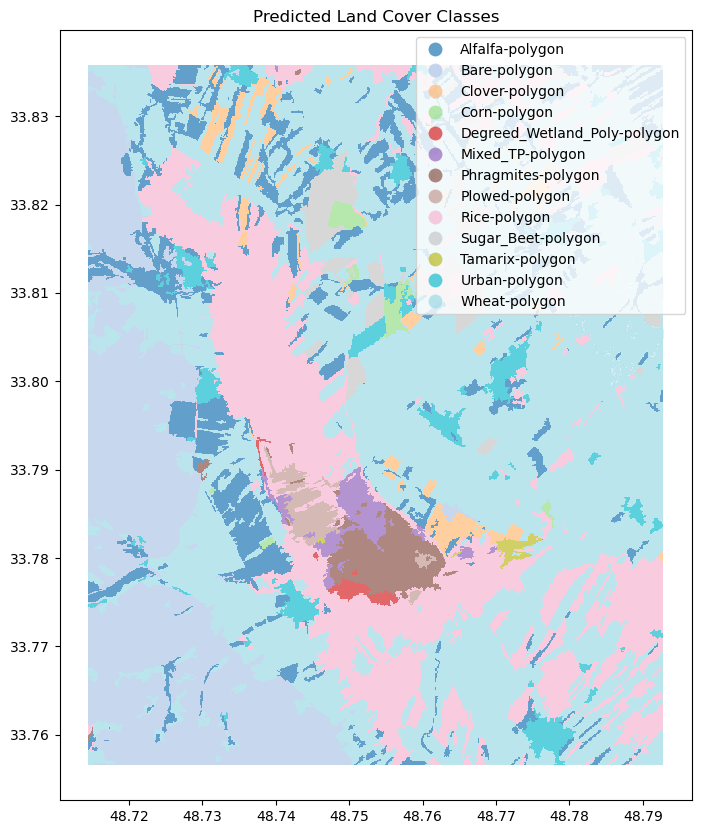

In [34]:
# ========================================================
# STEP 5: Predict on All Segments (FINAL FIXED VERSION)
# ========================================================
print("\n🔍 STEP 5: Predicting classes for all segments")

# 1. First get segment_ids from processed_seg_gdf
if 'segment_id' not in processed_seg_gdf.columns:
    processed_seg_gdf = processed_seg_gdf.reset_index().rename(columns={'index': 'segment_id'})
segment_ids = processed_seg_gdf['segment_id'].values

# 2. Prepare the feature matrix (without creating a segment_id column)
features_full = []
for segment_id in tqdm(segment_ids, desc="Preparing segments for prediction"):
    segment_data = final_merged_df[final_merged_df['segment_id'] == segment_id]
    segment_data = segment_data.sort_values('date')
    
    # Create feature dictionary without segment_id
    segment_feature = {}
    for _, row in segment_data.iterrows():
        date_str = row['date'].strftime('%Y%m%d')
        
        # Add all VIs and bands
        for vi in ['NDVI', 'EVI', 'SAVI', 'TDVI', 'NDWI', '2BDA', 'NDCI', 'ENDVI', 
                  'GNDVI', 'NDRE', 'GRVI', 'MSAVI', 'LSWI', 'NDMI', 'MNDWI', 
                  'MBI', 'EMBI', 'MCARI2']:
            segment_feature[f'{date_str}_{vi}'] = row[vi]
            
        for band in ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']:
            segment_feature[f'{date_str}_{band}'] = row[f'{band}_value']
    
    features_full.append(segment_feature)

# 3. Create DataFrame and align with training columns
X_full = pd.DataFrame(features_full)
X_full = X_full.reindex(columns=X_train.columns, fill_value=0)

# 4. Make predictions
print("\nPredicting probabilities...")
y_full_proba = rf.predict_proba(X_full)
y_full_pred = rf.predict(X_full)
y_full_labels = label_encoder.inverse_transform(y_full_pred)

# 5. Create results DataFrame with segment_ids
prediction_df = pd.DataFrame({
    'segment_id': segment_ids,
    'pred_class': y_full_labels
})

# Add probabilities
for i, class_name in enumerate(label_encoder.classes_):
    prediction_df[f'prob_{class_name}'] = y_full_proba[:, i]

# 6. Merge back with original data
processed_seg_gdf = processed_seg_gdf.merge(
    prediction_df,
    on='segment_id',
    how='left'
)

print("\n✅ Prediction completed successfully!")
print(f"Predicted classes distribution:")
print(processed_seg_gdf['pred_class'].value_counts())

# Visualization
print("\n🌍 Visualizing predictions...")
fig, ax = plt.subplots(figsize=(12, 10))
processed_seg_gdf.plot(
    column='pred_class',
    categorical=True,
    legend=True,
    ax=ax,
    cmap='tab20',
    alpha=0.7
)
ax.set_title("Predicted Land Cover Classes")
plt.show()

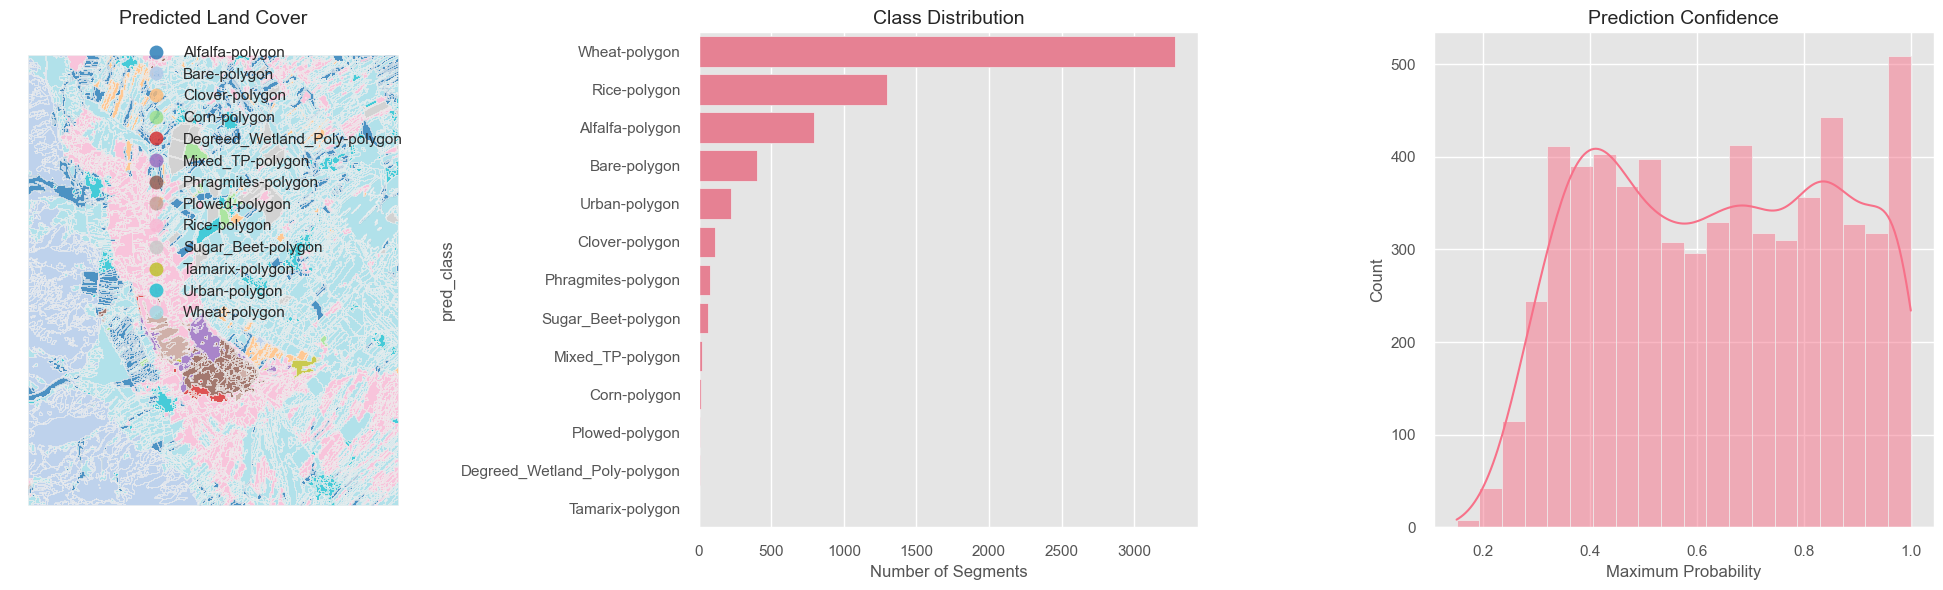


🗺️ 4. Spatial Confidence Distribution


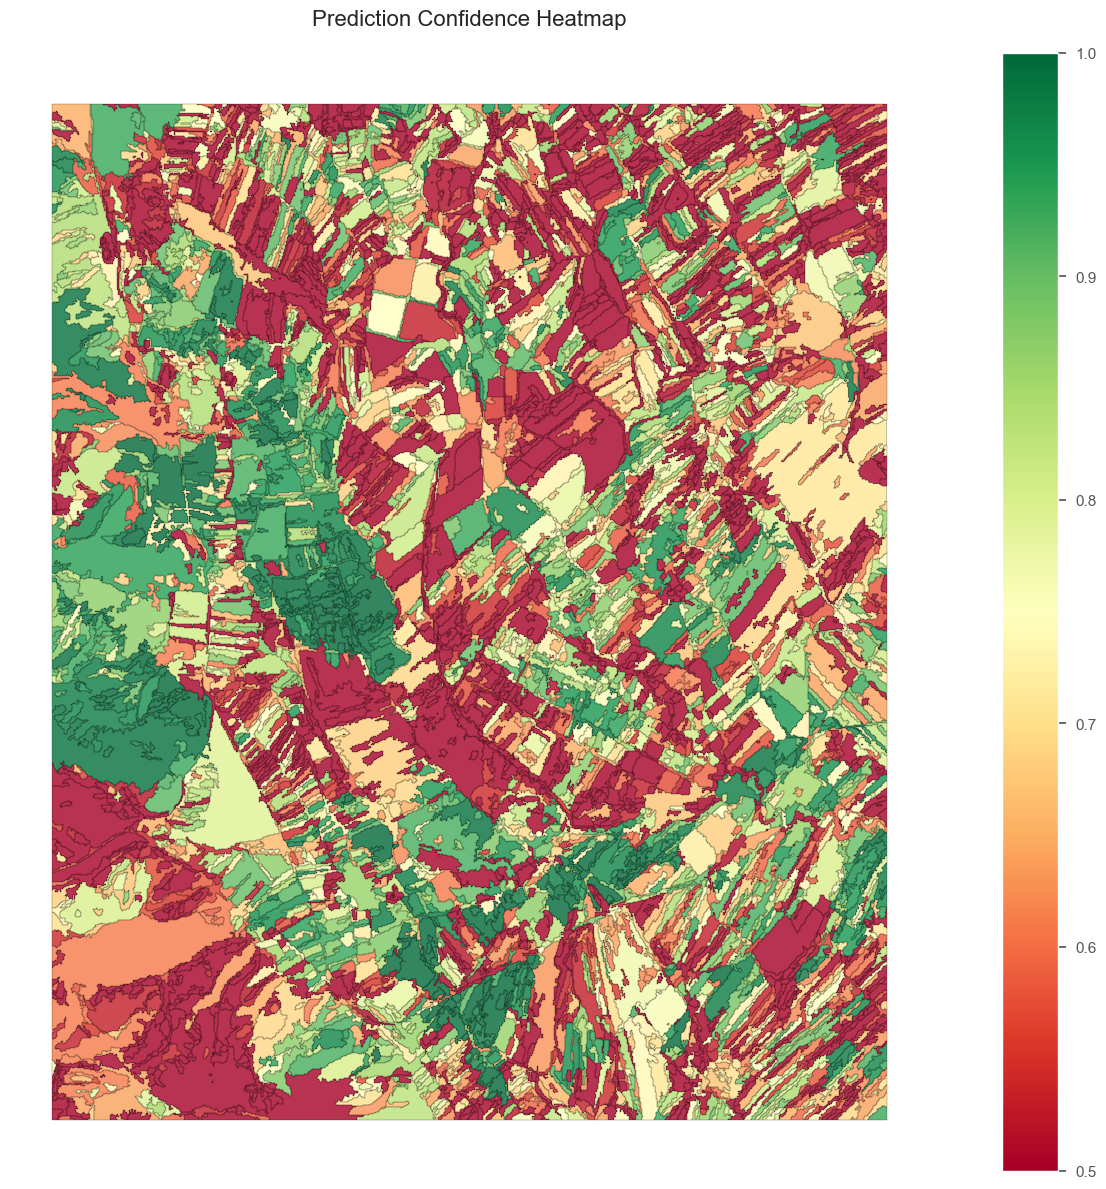


🔄 5. Temporal Analysis (Sample)


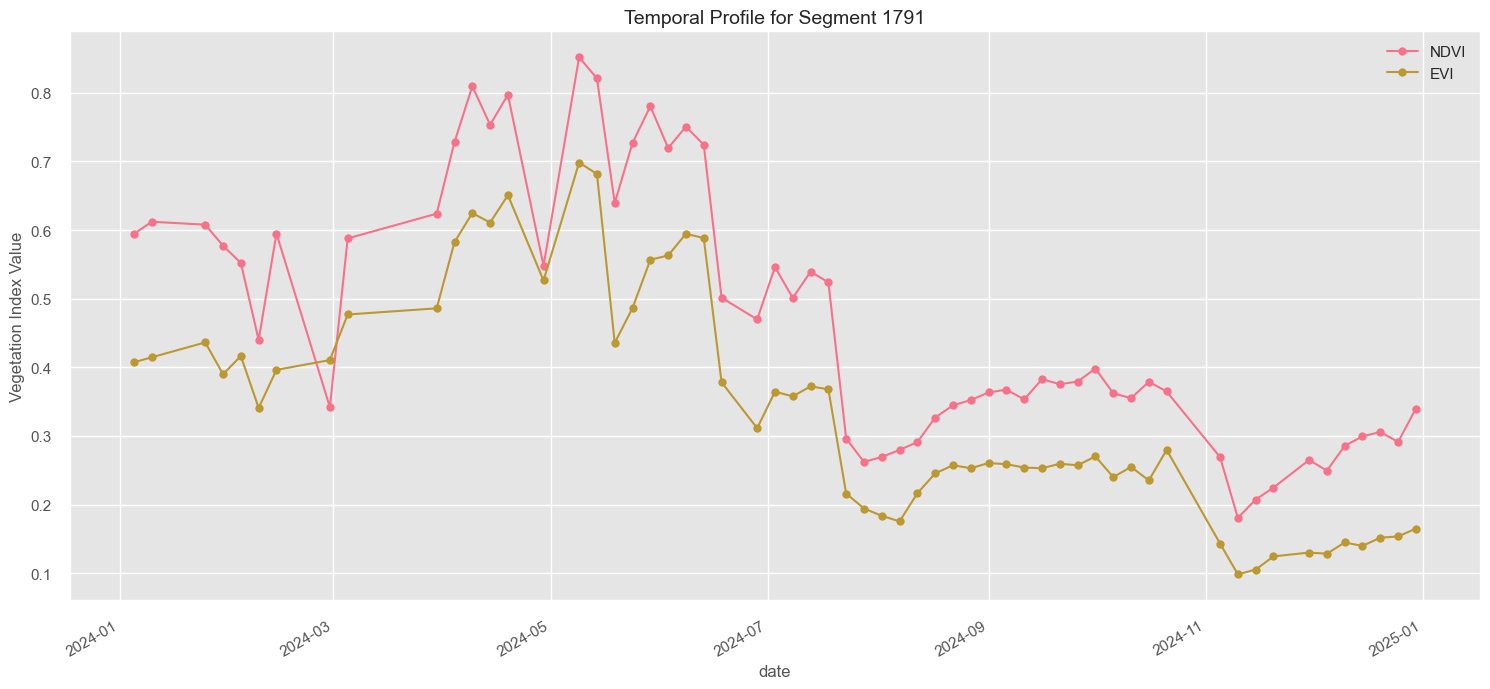


📈 6. Top Feature Importance


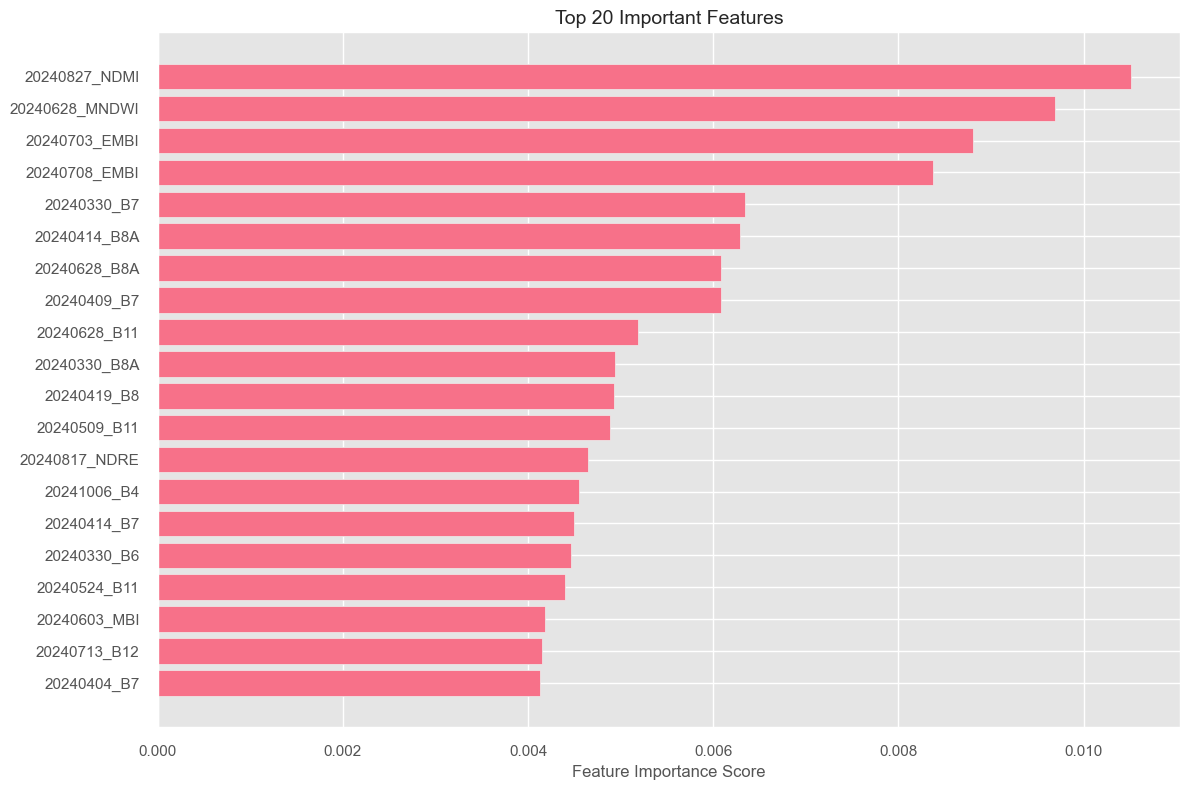


✅ All visualizations completed!


In [37]:
# ========================================================
# STEP 5: Enhanced Visualization Suite
# ========================================================
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Set style that works across matplotlib versions
plt.style.use('ggplot')  # Alternative clean style
sns.set_palette("husl")

# Create figure with 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# 1. Prediction Map
processed_seg_gdf.plot(
    column='pred_class',
    categorical=True,
    legend=True,
    ax=ax1,
    cmap='tab20',
    alpha=0.8
)
ax1.set_title("Predicted Land Cover", fontsize=14)
ax1.set_axis_off()

# 2. Class Distribution
class_counts = processed_seg_gdf['pred_class'].value_counts()
sns.barplot(x=class_counts.values, y=class_counts.index, ax=ax2, orient='h')
ax2.set_title("Class Distribution", fontsize=14)
ax2.set_xlabel("Number of Segments")

# 3. Confidence Distribution
processed_seg_gdf['max_prob'] = processed_seg_gdf[[f'prob_{c}' for c in label_encoder.classes_]].max(axis=1)
sns.histplot(processed_seg_gdf['max_prob'], bins=20, kde=True, ax=ax3)
ax3.set_title("Prediction Confidence", fontsize=14)
ax3.set_xlabel("Maximum Probability")

plt.tight_layout()
plt.show()
# 4. Spatial Confidence Map
print("\n🗺️ 4. Spatial Confidence Distribution")
fig, ax = plt.subplots(figsize=(15, 12))
processed_seg_gdf.plot(
    column='max_prob',
    legend=True,
    ax=ax,
    cmap='RdYlGn',
    vmin=0.5,
    vmax=1.0,
    alpha=0.8,
    edgecolor='black',
    linewidth=0.2
)
ax.set_title("Prediction Confidence Heatmap", fontsize=16, pad=20)
ax.set_axis_off()
plt.tight_layout()
plt.show()

# 5. Class Transition Analysis (if temporal data available)
print("\n🔄 5. Temporal Analysis (Sample)")
# Select a random segment with multiple observations
sample_seg = processed_seg_gdf.sample(1).iloc[0]['segment_id']
temporal_data = final_merged_df[final_merged_df['segment_id'] == sample_seg].sort_values('date')

if len(temporal_data) > 1:
    fig, ax = plt.subplots(figsize=(15, 7))
    
    # Plot NDVI and EVI over time
    temporal_data.plot(x='date', y=['NDVI', 'EVI'], ax=ax, marker='o')
    ax.set_title(f"Temporal Profile for Segment {sample_seg}", fontsize=14)
    ax.set_ylabel("Vegetation Index Value")
    ax.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient temporal data for demonstration")

# 6. Feature Importance (if available)
try:
    print("\n📈 6. Top Feature Importance")
    importances = rf.feature_importances_
    top_n = 20
    indices = np.argsort(importances)[-top_n:]
    
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(range(top_n), importances[indices], align='center')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([X_train.columns[i] for i in indices])
    ax.set_title("Top 20 Important Features", fontsize=14)
    ax.set_xlabel("Feature Importance Score")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Could not plot feature importance: {str(e)}")

print("\n✅ All visualizations completed!")

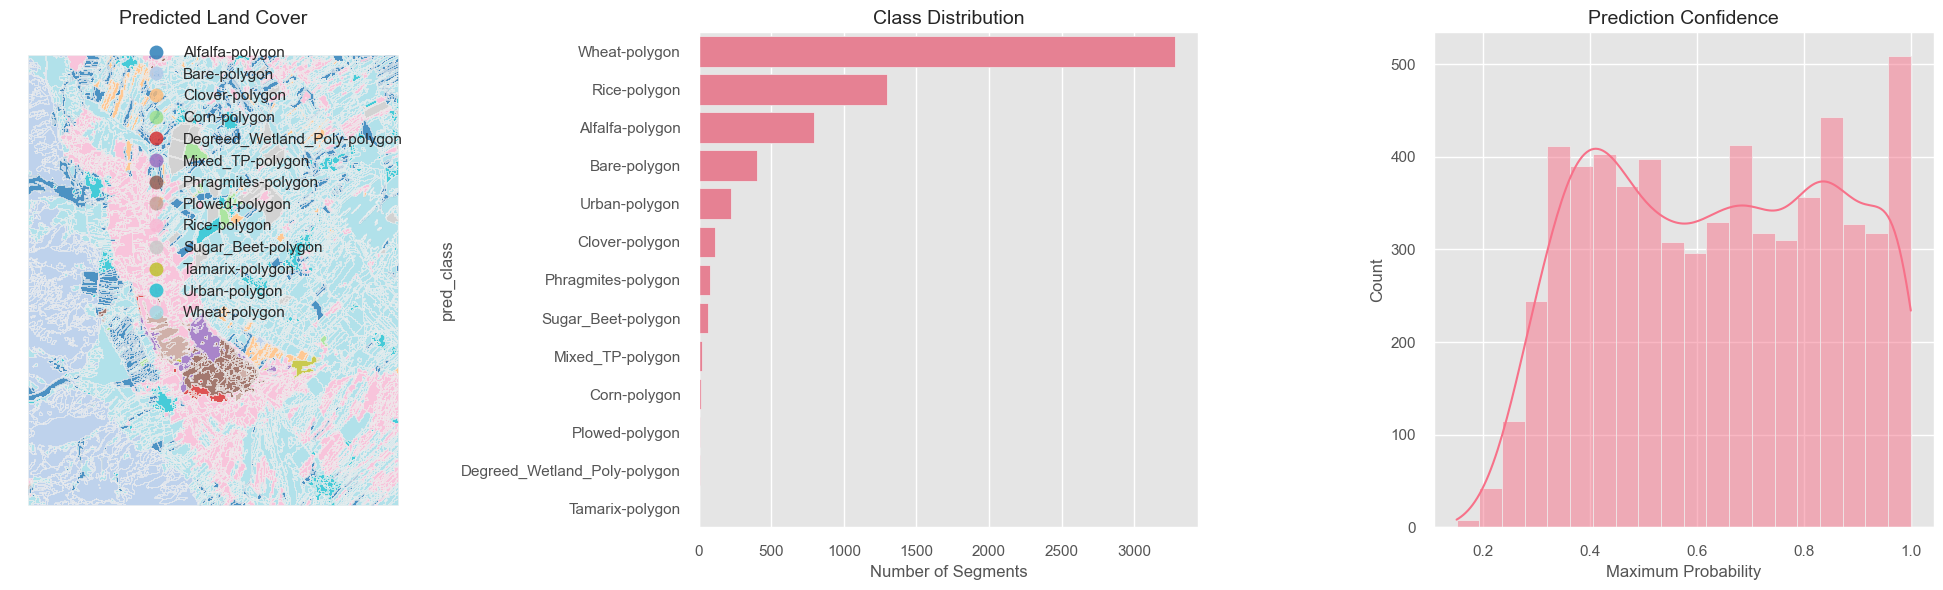


🔍 STEP 6: Visualizing and comparing prediction results


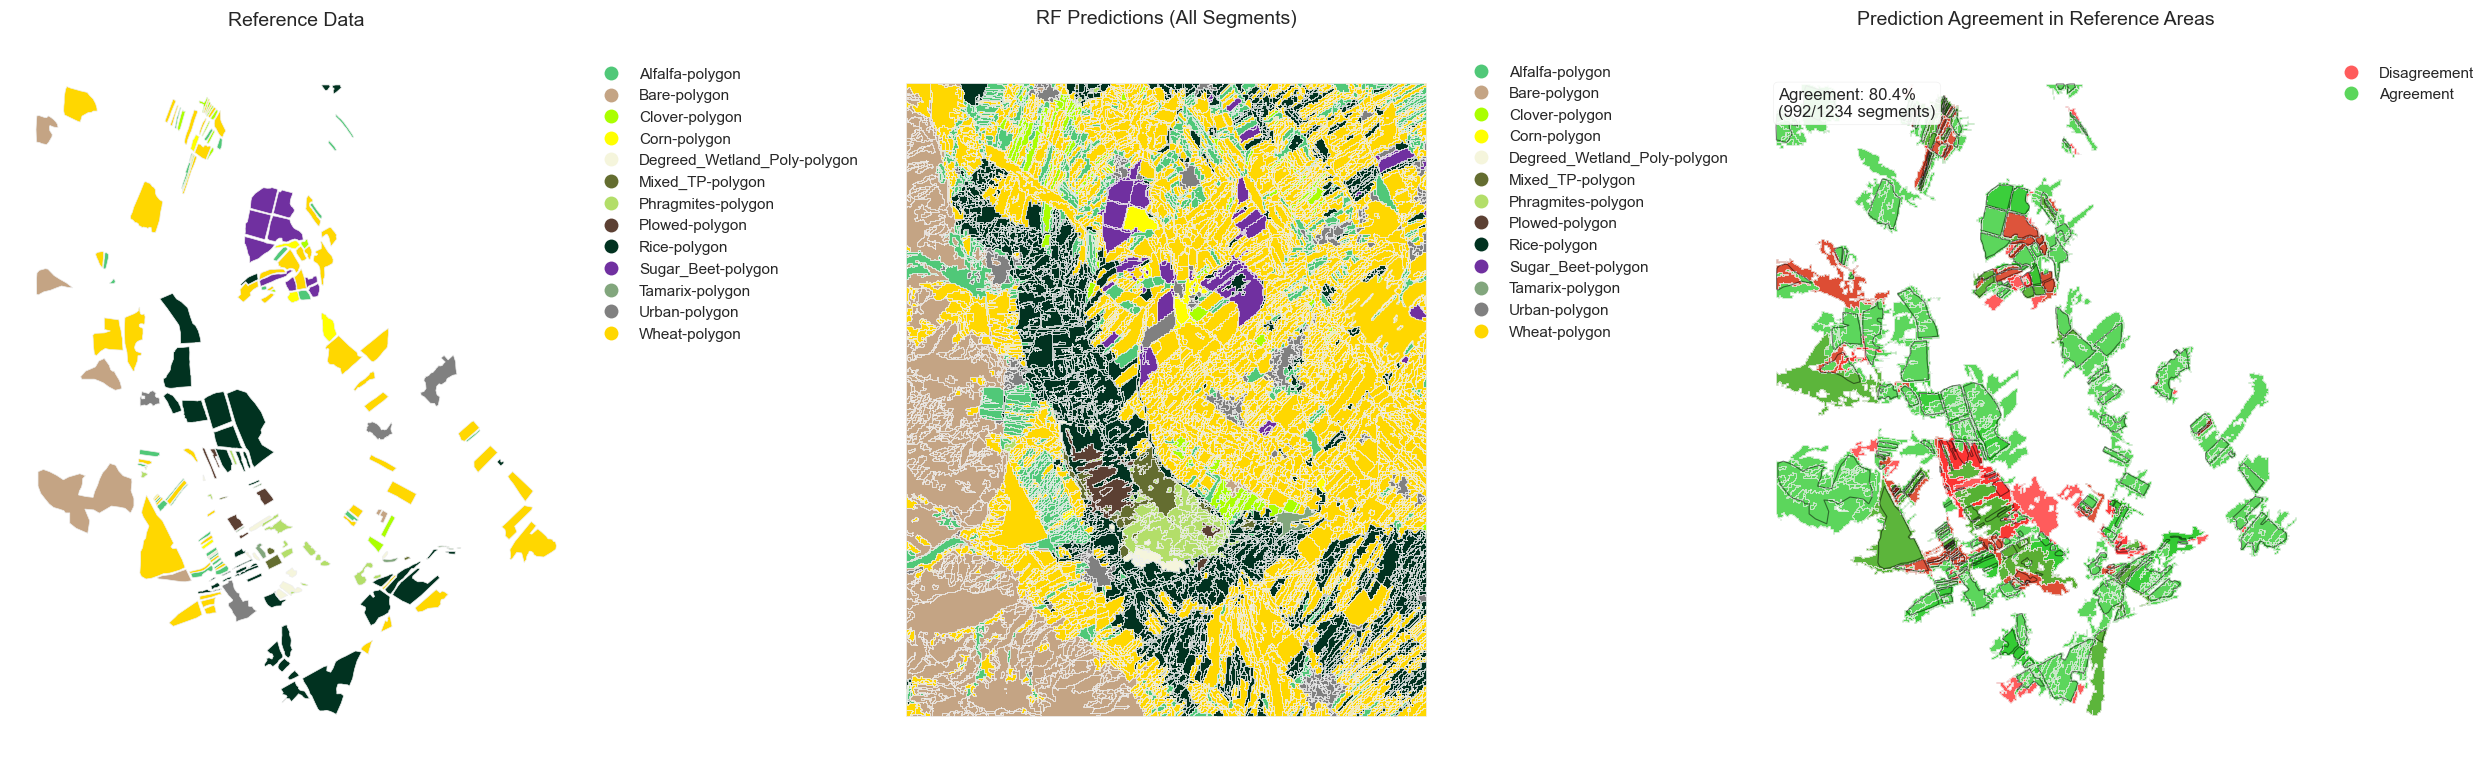


🔍 Class-wise Accuracy Analysis


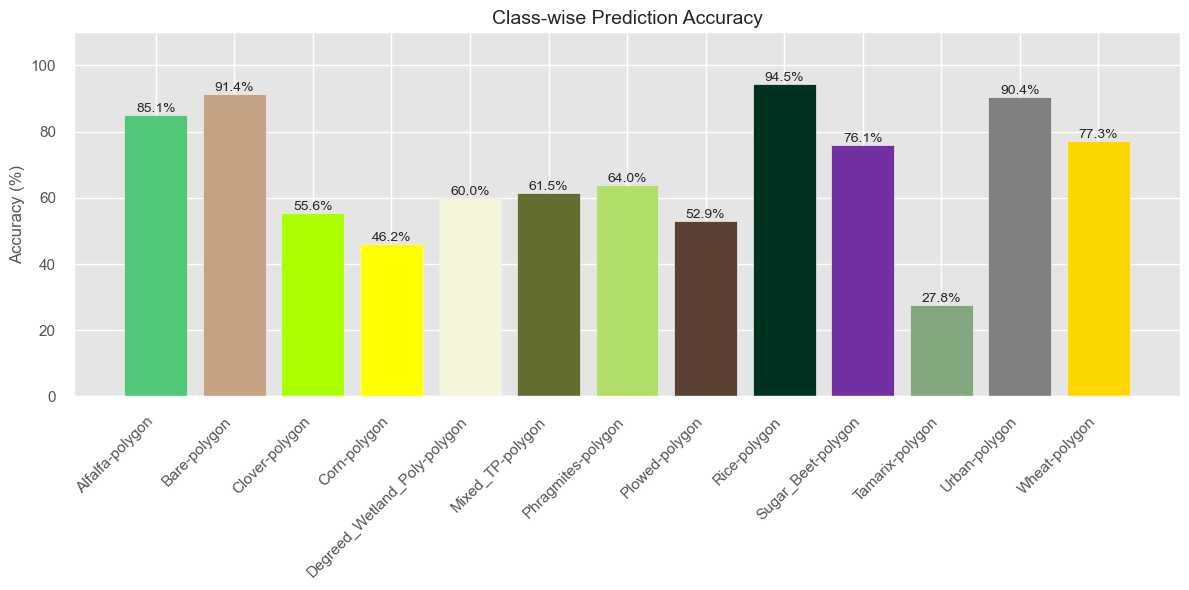


Class-wise Accuracy Metrics (matches confusion matrix order):
                       Class  Correct  Total  Accuracy
             Alfalfa-polygon      103    121 85.123967
                Bare-polygon       64     70 91.428571
              Clover-polygon       35     63 55.555556
                Corn-polygon       12     26 46.153846
Degreed_Wetland_Poly-polygon       12     20 60.000000
            Mixed_TP-polygon        8     13 61.538462
          Phragmites-polygon       32     50 64.000000
              Plowed-polygon        9     17 52.941176
                Rice-polygon      327    346 94.508671
          Sugar_Beet-polygon       35     46 76.086957
             Tamarix-polygon        5     18 27.777778
               Urban-polygon       47     52 90.384615
               Wheat-polygon      303    392 77.295918


In [39]:

# ========================================================
# STEP 6: Enhanced Results Visualization with Focused Overlay
# ========================================================
print("\n🔍 STEP 6: Visualizing and comparing prediction results")

# Create figure with 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(25, 10))

# Custom color palette matching the classes in your confusion matrix
class_palette = {
    'Alfalfa-polygon': '#50C878',
    'Bare-polygon': '#C4A484',
    'Clover-polygon': '#AAFF00',
    'Corn-polygon': '#FFFF00',
    'Degreed_Wetland_Poly-polygon': '#F5F5DC',
    'Mixed_TP-polygon': '#646D30',
    'Phragmites-polygon': '#b3de69',
    'Plowed-polygon': '#5C4033',
    'Rice-polygon': '#013220',
    'Sugar_Beet-polygon': '#7030A0',
    'Tamarix-polygon': '#82A67D',
    'Urban-polygon': '#808080',
    'Wheat-polygon': '#FFD700'
}

# --- Plot 1: Reference Data ---
ref_gdf.plot(column='layer', ax=ax1, 
            categorical=True,
            cmap=ListedColormap([class_palette[cls] for cls in class_palette]),
            legend=True,
            legend_kwds={'loc': 'upper left', 'bbox_to_anchor': (1, 1)})
ax1.set_title('Reference Data', fontsize=14, pad=20)
ax1.set_axis_off()

# --- Plot 2: Predictions (All Segments) ---
processed_seg_gdf.plot(column='pred_class', ax=ax2, 
                     categorical=True,
                     cmap=ListedColormap([class_palette[cls] for cls in class_palette]),
                     legend=True,
                     legend_kwds={'loc': 'upper left', 'bbox_to_anchor': (1, 1)})
ax2.set_title('RF Predictions (All Segments)', fontsize=14, pad=20)
ax2.set_axis_off()

# --- Plot 3: Focused Agreement/Disagreement ---
# Calculate IoU for each segment
joined = gpd.sjoin(processed_seg_gdf, ref_gdf, how='inner', predicate='intersects')

# Create agreement column (True where prediction matches reference)
joined['agreement'] = joined['pred_class'] == joined['layer']

# Convert to categorical for better plotting
joined['agreement'] = joined['agreement'].astype('category')

# Create a custom colormap for agreement
agreement_cmap = ListedColormap(['#ff3333', '#33cc33'])  # Red=disagree, Green=agree

# Plot only segments that intersect with reference polygons
joined.plot(column='agreement', 
           ax=ax3, 
           categorical=True,
           cmap=agreement_cmap,
           alpha=0.8,
           legend=True,
           legend_kwds={'labels': ['Disagreement', 'Agreement'], 'loc': 'upper left', 'bbox_to_anchor': (1, 1)})

# Add reference boundaries for context
ref_gdf.boundary.plot(ax=ax3, color='black', linewidth=0.8, alpha=0.5)

# Calculate and display accuracy metrics
total_segments = len(joined)
correct_segments = joined['agreement'].cat.codes.sum()  # True=1, False=0
agreement_perc = (correct_segments / total_segments) * 100

# Add text box with metrics
textstr = f"Agreement: {agreement_perc:.1f}%\n({correct_segments}/{total_segments} segments)"
props = dict(boxstyle='round', facecolor='white', alpha=0.9)
ax3.text(0.05, 0.95, textstr, transform=ax3.transAxes,
        verticalalignment='top', bbox=props, fontsize=12)

ax3.set_title('Prediction Agreement in Reference Areas', fontsize=14, pad=20)
ax3.set_axis_off()

plt.tight_layout()
plt.savefig('prediction_agreement.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

# --- Additional Visualization: Class-wise Accuracy ---
print("\n🔍 Class-wise Accuracy Analysis")

# Calculate class-specific accuracy
class_accuracy = []
for cls in sorted(ref_gdf['layer'].unique()):
    # Get reference polygons of this class
    ref_mask = joined['layer'] == cls
    if ref_mask.sum() > 0:  # Only process if class exists in reference
        class_correct = (joined[ref_mask]['pred_class'] == cls).sum()
        class_total = ref_mask.sum()
        class_accuracy.append({
            'Class': cls,
            'Correct': class_correct,
            'Total': class_total,
            'Accuracy': (class_correct / class_total) * 100
        })

# Create dataframe and sort by class name to match confusion matrix
accuracy_df = pd.DataFrame(class_accuracy).sort_values('Class')

# Plot class accuracy with matching colors
plt.figure(figsize=(12, 6))
bars = plt.bar(accuracy_df['Class'], accuracy_df['Accuracy'], 
              color=[class_palette[cls] for cls in accuracy_df['Class']])
plt.title('Class-wise Prediction Accuracy', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 110)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%',
             ha='center', va='bottom')

plt.tight_layout()
plt.savefig('Class-wise Prediction Accuracy.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

# Print class accuracy table
print("\nClass-wise Accuracy Metrics (matches confusion matrix order):")
print(accuracy_df.to_string(index=False))